   ---------------------------------------- 0.0/671.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.7 kB ? eta -:--:--
   --------------- ------------------------ 262.1/671.7 kB ? eta -:--:--
   ------------------------------- -------- 524.3/671.7 kB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 671.7/671.7 kB 2.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


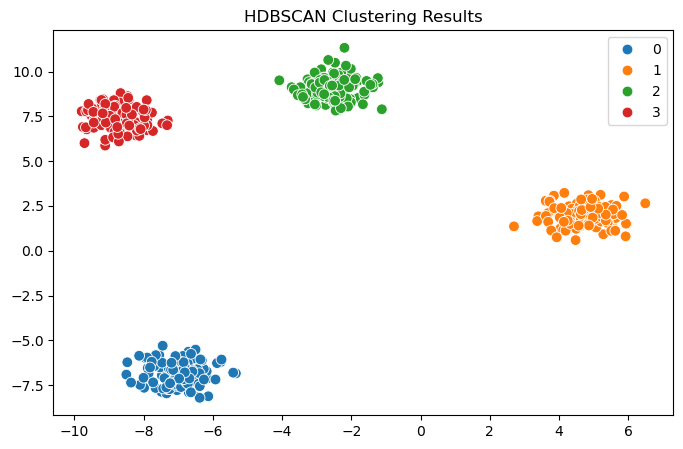

Evaluation Metrics (excluding noise):
 - Silhouette Score: 0.876
 - Calinski-Harabasz Index: 15874.713
 - Davies-Bouldin Index: 0.175


In [1]:

%pip install hdbscan

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import hdbscan


X, y_true = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=0.60, random_state=42)


clusterer = hdbscan.HDBSCAN(min_cluster_size=10, metric='euclidean')
labels = clusterer.fit_predict(X)


plt.figure(figsize=(8, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="tab10", s=60)
plt.title("HDBSCAN Clustering Results")
plt.show()



mask = labels != -1
X_filtered = X[mask]
labels_filtered = labels[mask]

if len(np.unique(labels_filtered)) > 1:
    silhouette = silhouette_score(X_filtered, labels_filtered)
    calinski = calinski_harabasz_score(X_filtered, labels_filtered)
    davies = davies_bouldin_score(X_filtered, labels_filtered)

    print("Evaluation Metrics (excluding noise):")
    print(f" - Silhouette Score: {silhouette:.3f}")
    print(f" - Calinski-Harabasz Index: {calinski:.3f}")
    print(f" - Davies-Bouldin Index: {davies:.3f}")
else:
    print("Not enough clusters to compute evaluation metrics.")